In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import collections
import itertools
import functools
import os
import pathlib
import shutil
import datetime

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.decomposition
import plotly.express as px
import scipy
import statsmodels.stats.multitest
import decoupler

import common_data
import common_plots
import factor_interpretation as fi

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [4]:
common_plots.setup_plotting()

# Principal component analysis plots, production

Cell types selected by MOFA
- MRC1+C1QA+
- MRC1+C1QA-
- CD8 T cells

For each cell type:
1. categorical heatmap
2. numerical heatmap
3. pc1 vs pc2
4. pc1 vs pc2 ellipses

In [ ]:
ROOT = common_data.DATA
BASE = ROOT / '05_pseudobulk/01_all_pseudobulk'

In [6]:
TOP_N_GENES = 2000
TOP_N_PCS = 10

In [8]:
PRETTY_CAT_NAMES = {
    'Episode_etiology': 'Adjudicated pathogen',
    'Pathogen_virus_detected': 'Virus not detected',
    'Pathogen_bacteria_detected': 'Bacteria detected',
    'Global_cause_failure': 'Overall adjudicated outcome',
    'VAP_is_cured_d7': 'VAP cure in 7 days',
    'Pathogen_fungi_detected': 'Fungi detected',
    'Episode_is_cured': 'Episode cured',
    'Binary_outcome': 'Mortality',
    'Sex': 'Female sex',
    'Smoking_status': 'No smoking history',
    'Episode_category': 'CAP / HAP / VAP / NPC',
    'Healthy_vs_NPC_vs_Pathogen': 'Healthy / NPC / Viral, bacterial or mixed',
    'Flow_clusters': 'Flow cytometry clusters',
    'ScRNAseq_clusters': 'scRNA-seq clusters'
}

In [ ]:
sc_meta = pd.read_csv(
    common_data.SC_META,
    index_col=0
)

/tmp/ipykernel_106759/4000152471.py:1: DtypeWarning: Columns (16,17,25,31,32,35,37,40,41,52,54,56,57,58,66) have mixed types. Specify dtype option on import or set low_memory=False.
  sc_meta = pd.read_csv(


In [10]:
pseudobulk_n_cells = sc_meta.groupby(['individual', 'Level_6']).size().reset_index(name='n_cells')

In [11]:
pseudobulk_n_cells = pseudobulk_n_cells.loc[pseudobulk_n_cells.n_cells.ge(50)].copy()

In [12]:
pseudobulk_n_cells.rename(columns={'individual': 'sample', 'Level_6': 'cell_type'}, inplace=True)

In [13]:
sample_meta = sc_meta.groupby('individual').head(1)[
    ['days_on_ventilator', 'sequencing_depth', 'sequencing_saturation',
    'frac_reads_in_cells', 'viability', 'individual']
].set_index('individual')

In [14]:
categorical_covariates = common_data.get_sc_categorical_covariates()

In [15]:
numerical_covariates = common_data.get_sc_numerical_covariates()

In [16]:
na_values = {col: 'NA' for col in categorical_covariates.columns}
na_values.update(common_data.na_values)
na_values['Pathogen_groups'] = ['Healthy', 'NPC', 'discard']

In [17]:
categorical_covariates['Pathogen_groups'] = categorical_covariates[
    'Pathogen_groups'
].cat.rename_categories({
    'Pseudomonas aeruginosa': 'Pseudomonas',
    'Pseudomonas aeruginosa; SARS-CoV-2': 'Pseudomonas; SARS-CoV-2'
})

In [18]:
healthy_samples = categorical_covariates.index[categorical_covariates.Pathogen_groups.eq('Healthy')]

In [ ]:
class CellTypeInfo:
    def __init__(self, path, additional_meta):
        self.path = path
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.meta = self.meta.merge(additional_meta, left_on='sample', right_index=True)
        for c in self.meta.columns:
            if pd.api.types.is_categorical_dtype(self.meta[c]):
                self.meta[c] = self.meta[c].cat.remove_unused_categories()
        self.meta['is_healthy'] = self.meta['sample'].isin(healthy_samples)
        self.name = self.meta.cell_type.values[0]
        self.vst = pd.read_table(path / 'transformed.tsv', delim_whitespace=True).T
        # subset
        self.meta = self.meta.loc[self.meta['sample'].isin(additional_meta.index)]
        self.vst = self.vst.loc[self.meta['sample']]
        self.run_pca()

    def select_top_genes(self):
        top_genes = self.vst.var(axis=0).sort_values().index[-TOP_N_GENES:]
        return self.vst.loc[:, top_genes].copy()

    def run_pca(self):
        self.top_vst = self.select_top_genes()
        self.pca = sklearn.decomposition.PCA()
        self.pcs = self.pca.fit_transform(self.top_vst)

    def plot_pca_elbow(self):
        to_plot = min(50, self.pca.n_components_)
        fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
        ax.bar(range(to_plot), self.pca.explained_variance_ratio_[:to_plot] * 100)
        ax.set_xlabel('PC', size=14)
        ax.set_ylabel('% variance explained\n(top 2000 genes)', size=14)
        ax.set_title(self.name, size=16)
        return fig

    def get_pc_weights(self):
        n_pcs = min(self.pcs.shape[1], TOP_N_PCS)
        return pd.DataFrame(
            self.pca.components_[:n_pcs].T,
            index=self.top_vst.columns,
            columns='PC' + (pd.Series(range(n_pcs)) + 1).astype(str)
        ).sort_values('PC1')

    def get_pc_df(self, additional_meta):
        n_pcs = min(self.pcs.shape[1], TOP_N_PCS)
        pc_df = self.meta.copy()
        pc_df.loc[:, 'PC' + (pd.Series(range(n_pcs)) + 1).astype(str)] = self.pcs[:, :n_pcs]
        pc_df['size'] = pc_df.days_on_ventilator.copy()
        pc_df.fillna(0, inplace=True)
        pc_df.loc[pc_df['size'].lt(0), 'size'] = 0
        pc_df['size'] = (pc_df['size'] + 0.5) ** 0.5
        return pc_df

In [20]:
all_covariates = categorical_covariates.merge(numerical_covariates, left_index=True, right_index=True)

In [21]:
OUR_CELL_TYPES = [
    'MRC1+C1QA+', 'MRC1+C1QA-', 'CD8_T_cells'
]

In [22]:
data = []
for cell_type_path in OUR_CELL_TYPES:
    if not (BASE / cell_type_path / 'transformed.tsv').exists():
        continue
    info = CellTypeInfo(BASE / cell_type_path, all_covariates)
    data.append(info)

In [23]:
[(i.name, i.get_pc_df(all_covariates).shape) for i in data]

[('MRC1+C1QA+', (294, 80)),
 ('MRC1+C1QA-', (296, 80)),
 ('CD8 T cells', (277, 80))]

In [24]:
# From https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = mpl.patches.Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = mpl.transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [52]:
cell_type = data[0]
print(cell_type.name)
pc_df = cell_type.get_pc_df(sample_meta)
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(
    common_plots.PATHOGEN_ORDER
)

MRC1+C1QA+


In [53]:
ELLIPSES = (
    'Healthy',
    'NPC',
    'Early SARS-CoV-2',
    'Late SARS-CoV-2',
    'Pseudomonas'
)

Text(0.5, 1.0, 'MRC1+C1QA+')

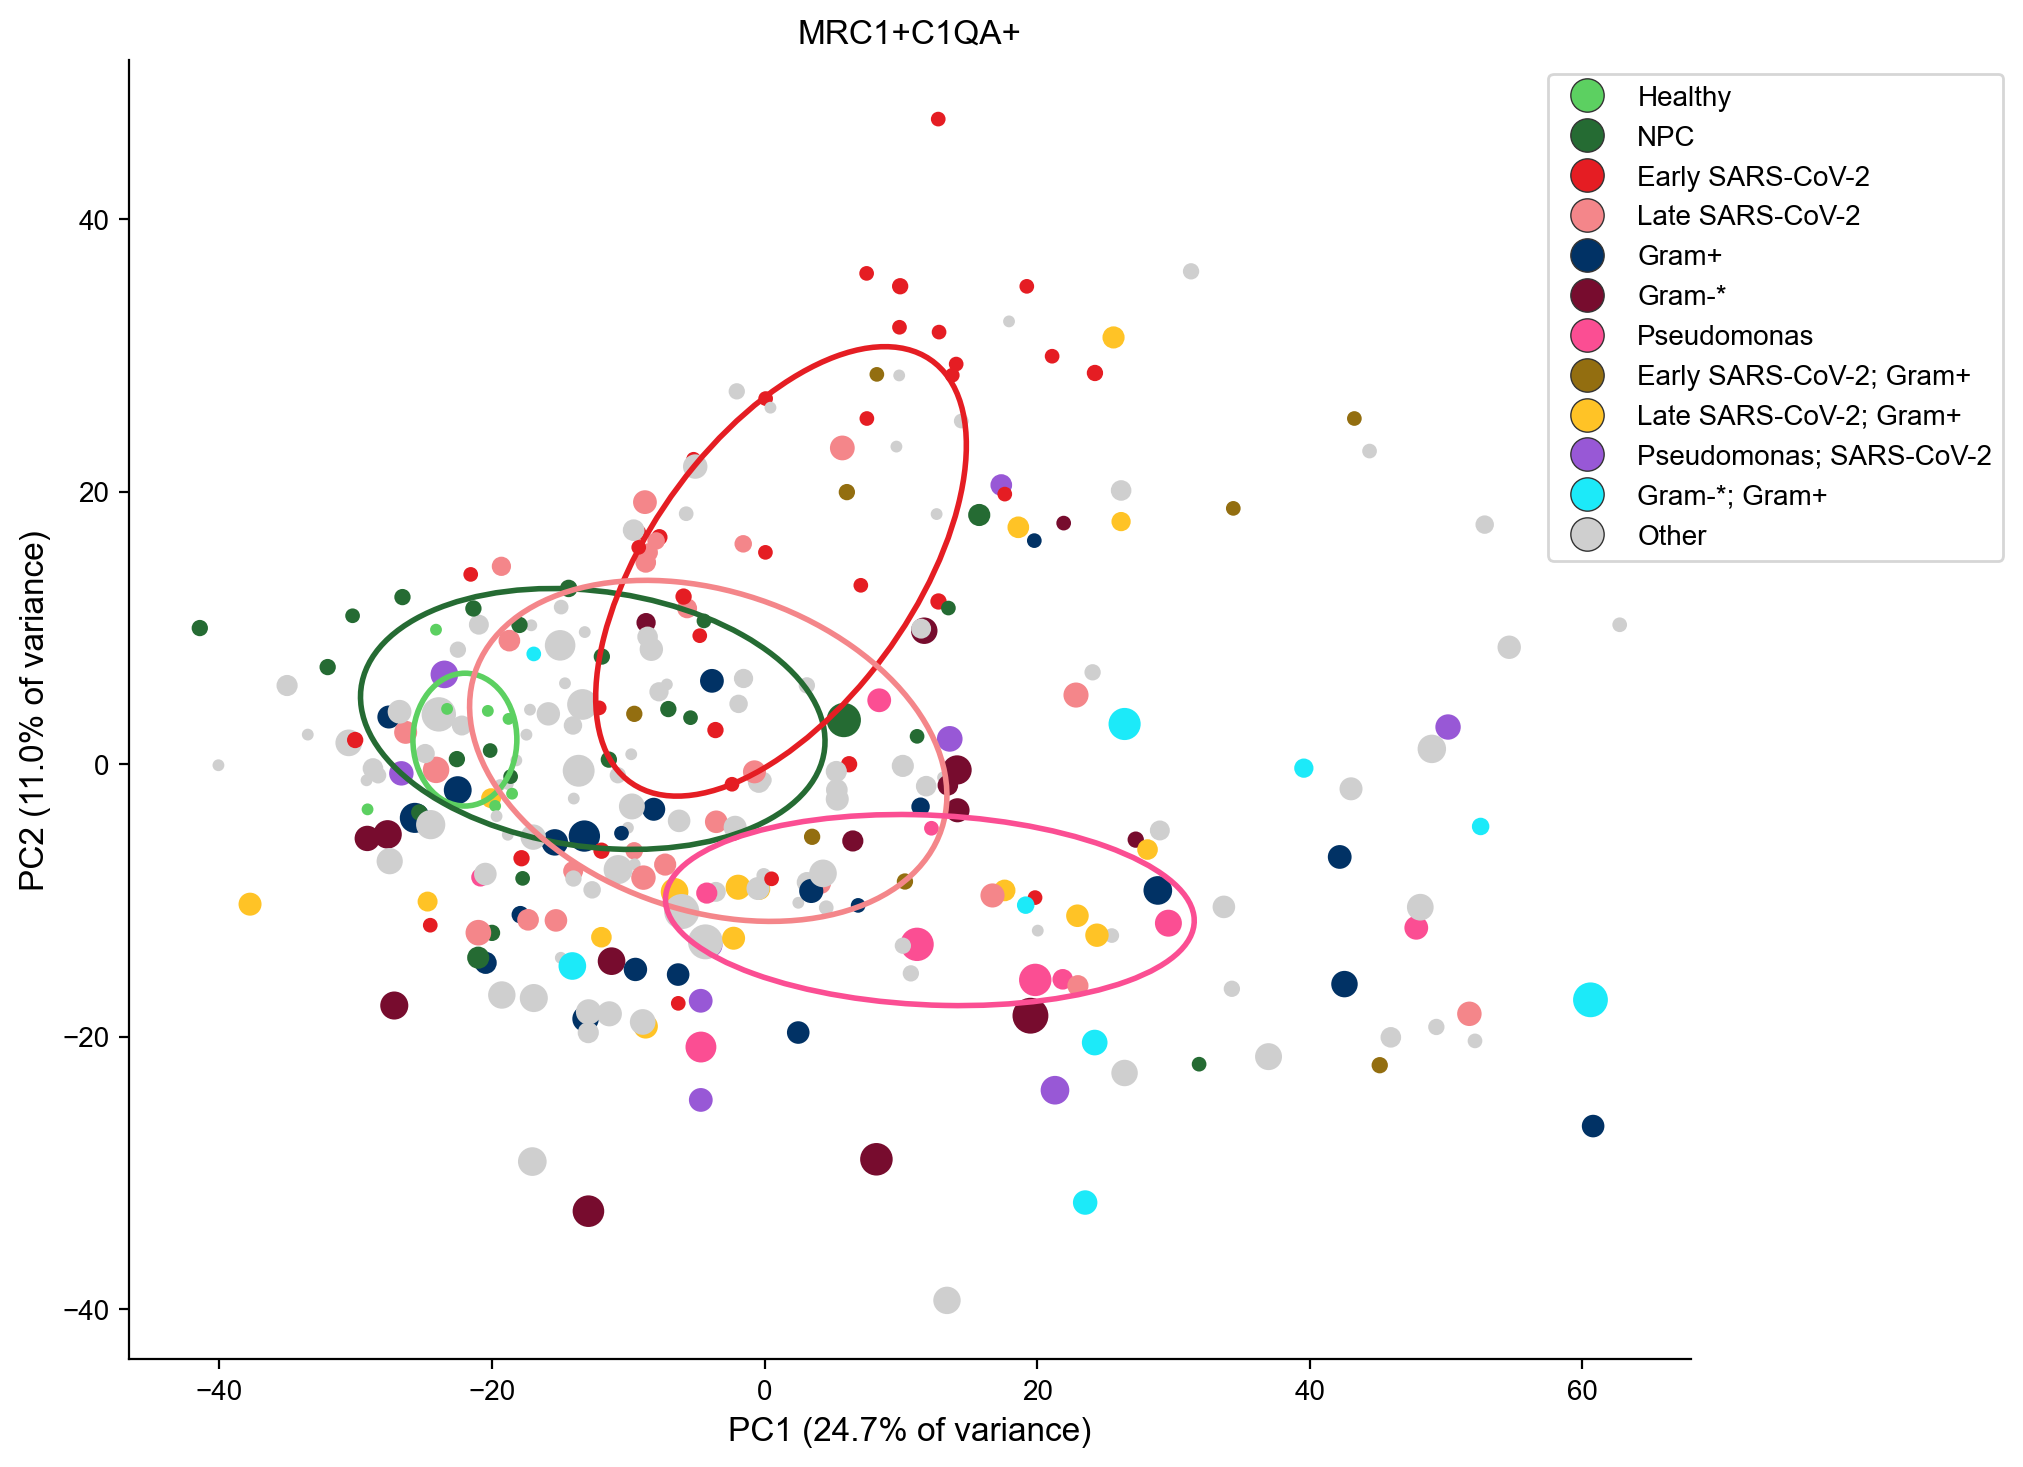

In [54]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.scatter(
    pc_df.PC1,
    pc_df.PC2,
    s=pc_df['size'] * 15,
    c=common_plots.get_color_annotations(pc_df, {
        'Pathogen_groups': [
            common_plots.PATHOGEN_PALETTE[cat]
            for cat
            in common_plots.PATHOGEN_ORDER
        ]
    }).Pathogen_groups
)
for cat in common_plots.PATHOGEN_ORDER:
    if cat not in ELLIPSES:
        continue
    idx = pc_df.Pathogen_groups.eq(cat)
    confidence_ellipse(
        pc_df.PC1[idx],
        pc_df.PC2[idx],
        ax,
        edgecolor=common_plots.PATHOGEN_PALETTE[cat],
        lw=2,
        n_std=1
    )
ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0], [0],
            ls='',
            marker='o',
            markerfacecolor=common_plots.PATHOGEN_PALETTE[cat],
            markeredgecolor='#333',
            markeredgewidth=0.5,
            markersize=12,
            label=cat if cat != 'discard' else 'Other'
        )
        for cat
        in common_plots.PATHOGEN_ORDER
    ],
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(0.9, 1),
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
pc1_label = f'PC1 ({cell_type.pca.explained_variance_ratio_[0] * 100:.1f}% of variance)'
pc2_label = f'PC2 ({cell_type.pca.explained_variance_ratio_[1] * 100:.1f}% of variance)'
ax.set_xlabel(pc1_label, size=12)
ax.set_ylabel(pc2_label, size=12)
ax.set_aspect('equal')
ax.set_title(cell_type.name)
# fig.savefig(f'00_plots/16f_pca_{cell_type.name}.pdf')

In [55]:
pc_names = pc_df.columns[pc_df.columns.str.startswith('PC')]
pc_df = pc_df.set_index('sample')

In [56]:
cat_covs = categorical_covariates.loc[pc_df.index].copy()
for col in cat_covs.columns:
    cat_covs[col] = cat_covs[col].cat.remove_unused_categories()

In [57]:
pc_cat_assoc = fi.test_association(
    pc_df.loc[:, pc_names],
    cat_covs,
    na_values,
    alternative_covariates=common_data.alternative_covariates
)
to_keep = pc_cat_assoc.lt(0.05).sum().gt(0)
pc_cat_assoc = pc_cat_assoc.loc[:, to_keep].copy()

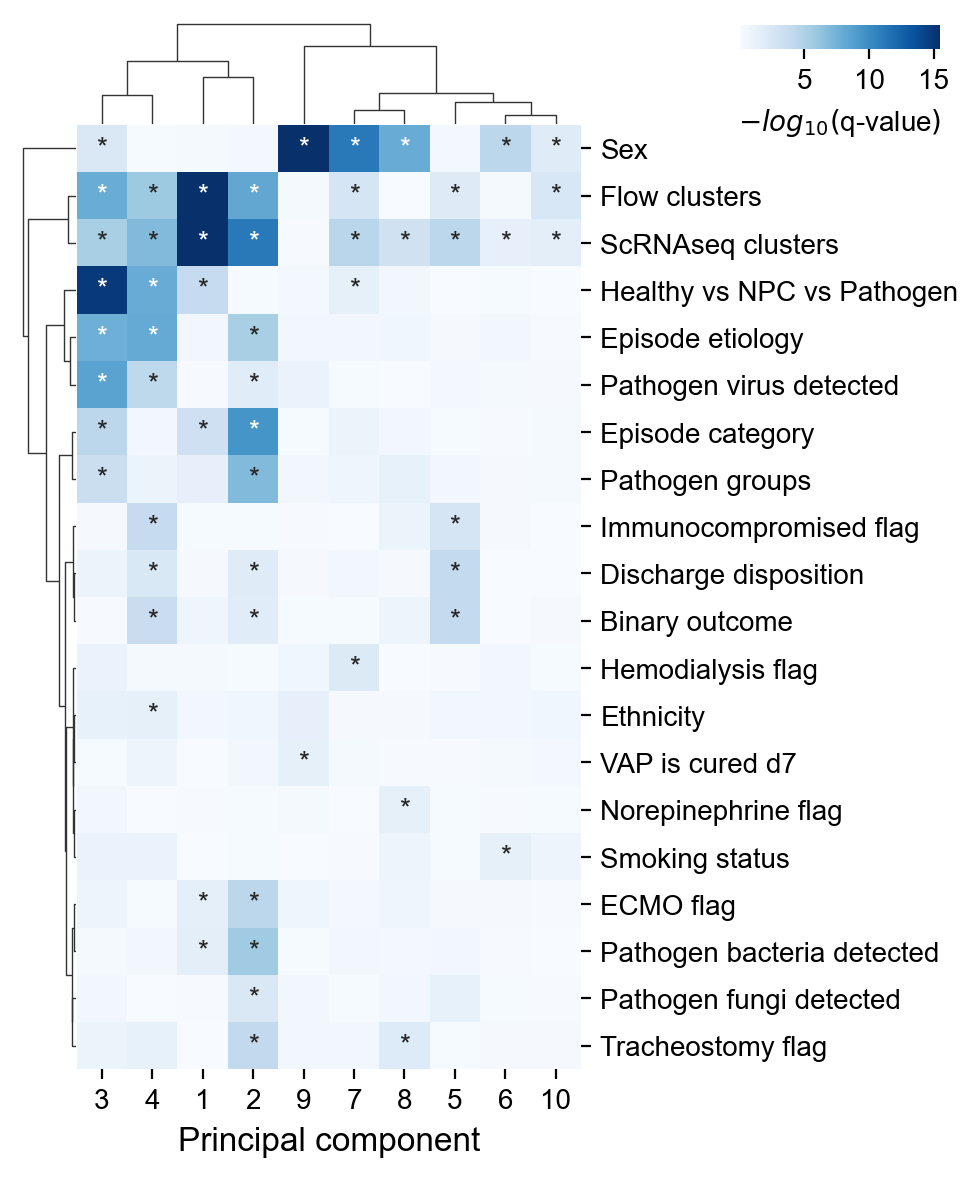

In [58]:
min_pval = pc_cat_assoc.to_numpy()[pc_cat_assoc != 0].min()
pc_cat_assoc[pc_cat_assoc == 0] = min_pval * 0.01
pc_annot = pd.DataFrame(index=pc_cat_assoc.index, columns=pc_cat_assoc.columns)
pc_annot[-np.log10(pc_cat_assoc) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    -np.log10(pc_cat_assoc).T,
    method='ward',
    cmap='Blues',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal'
    ),
    dendrogram_ratio=0.1,
    figsize=(5, 6),
    vmax=15.5,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=pc_cat_assoc.columns.str.replace('_', ' '),
    xticklabels=pc_cat_assoc.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.figure.subplots_adjust(bottom=0.1)
cg.ax_cbar.set_position((0.75, 0.95, 0.2, 0.02))
cg.figure.savefig(f'00_plots/17e_cat_heatmap_{cell_type.name}.pdf')

In [59]:
pc_corrs, pc_corr_pvals = fi.test_correlation(
    pc_df.loc[:, pc_names],
    numerical_covariates.loc[pc_df.index],
    na_values=dict(
        sequencing_depth=-1,
        sequencing_saturation=-1,
        frac_reads_in_cells=-1,
        viability=-1,
    )
)

In [60]:
to_keep = pc_corr_pvals.lt(0.05).sum().gt(0)
pc_corrs = pc_corrs.loc[:, to_keep].copy()
pc_corr_pvals = pc_corr_pvals.loc[:, to_keep].copy()

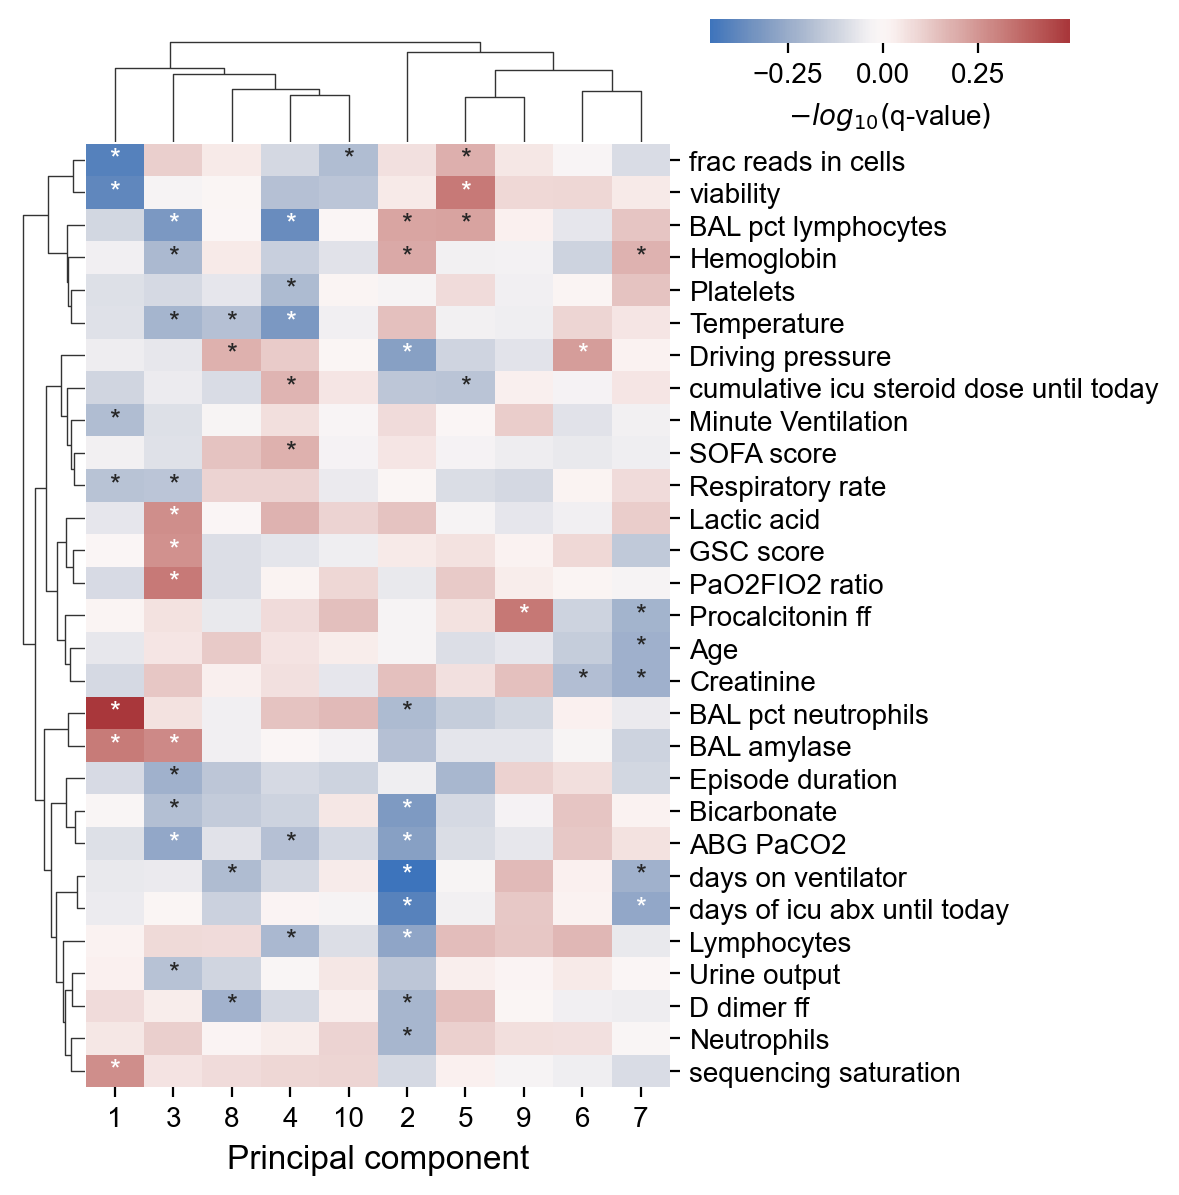

In [61]:
pc_annot = pd.DataFrame(index=pc_corr_pvals.index, columns=pc_corr_pvals.columns)
pc_annot[-np.log10(pc_corr_pvals) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    pc_corrs.T,
    method='ward',
    cmap='vlag',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal',
    ),
    dendrogram_ratio=0.1,
    figsize=(6, 6),
    center=0,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=pc_corrs.columns.str.replace('_', ' '),
    xticklabels=pc_corrs.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.fig.subplots_adjust(bottom=0.1)
cg.ax_cbar.set_position((0.6, 0.97, 0.3, 0.02))
# cg.fig.savefig(f'00_plots/16f_num_heatmap_{cell_type.name}.pdf')

In [62]:
cell_type = data[1]
print(cell_type.name)
pc_df = cell_type.get_pc_df(sample_meta)
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(
    common_plots.PATHOGEN_ORDER
)

MRC1+C1QA-


Text(0.5, 1.0, 'MRC1+C1QA-')

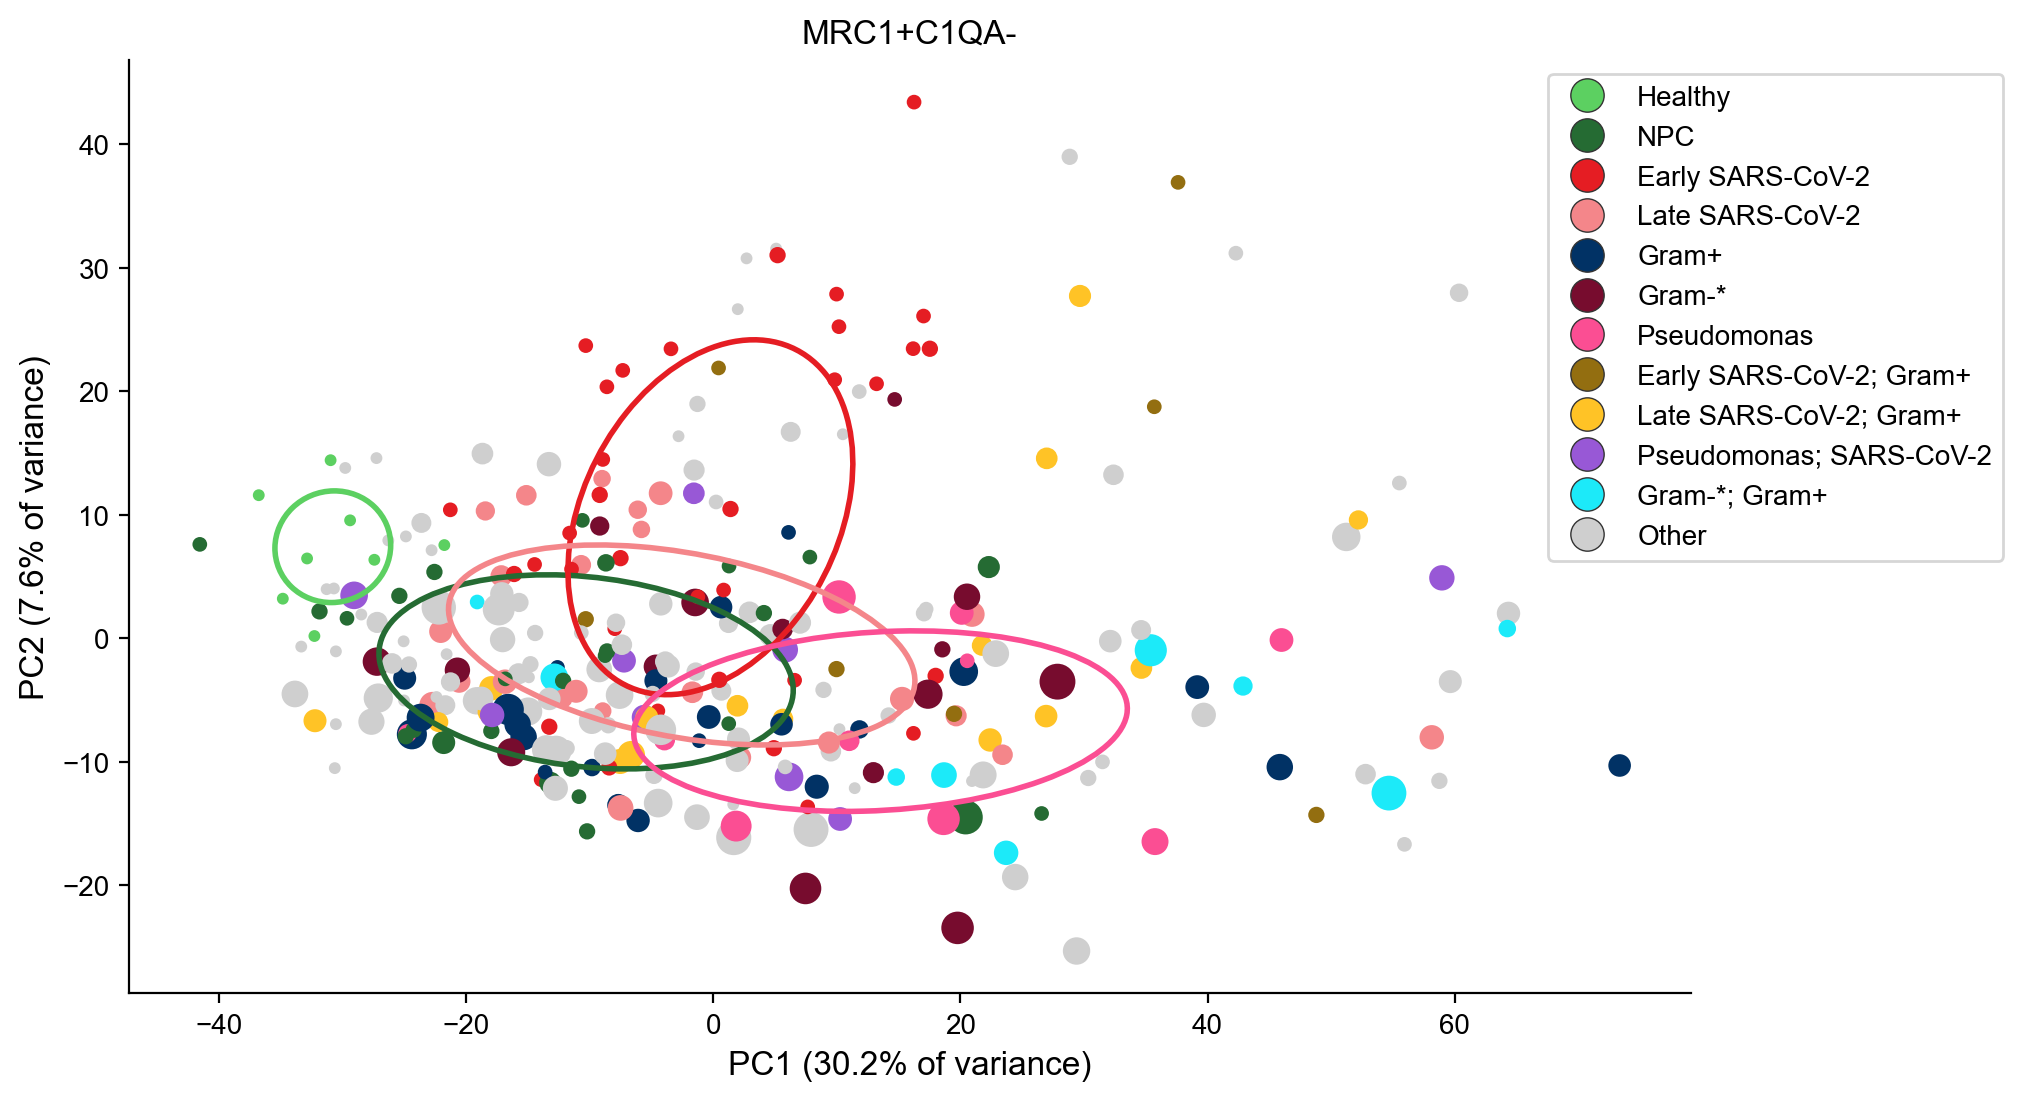

In [63]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.scatter(
    pc_df.PC1,
    pc_df.PC2,
    s=pc_df['size'] * 15,
    c=common_plots.get_color_annotations(pc_df, {
        'Pathogen_groups': [
            common_plots.PATHOGEN_PALETTE[cat]
            for cat
            in common_plots.PATHOGEN_ORDER
        ]
    }).Pathogen_groups
)
for cat in common_plots.PATHOGEN_ORDER:
    if cat not in ELLIPSES:
        continue
    idx = pc_df.Pathogen_groups.eq(cat)
    confidence_ellipse(
        pc_df.PC1[idx],
        pc_df.PC2[idx],
        ax,
        edgecolor=common_plots.PATHOGEN_PALETTE[cat],
        lw=2,
        n_std=1
    )
ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0], [0],
            ls='',
            marker='o',
            markerfacecolor=common_plots.PATHOGEN_PALETTE[cat],
            markeredgecolor='#333',
            markeredgewidth=0.5,
            markersize=12,
            label=cat if cat != 'discard' else 'Other'
        )
        for cat
        in common_plots.PATHOGEN_ORDER
    ],
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(0.9, 1),
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
pc1_label = f'PC1 ({cell_type.pca.explained_variance_ratio_[0] * 100:.1f}% of variance)'
pc2_label = f'PC2 ({cell_type.pca.explained_variance_ratio_[1] * 100:.1f}% of variance)'
ax.set_xlabel(pc1_label, size=12)
ax.set_ylabel(pc2_label, size=12)
ax.set_aspect('equal')
ax.set_title(cell_type.name)
# fig.savefig(f'00_plots/17e_pca_{cell_type.name}.pdf')

In [64]:
pc_names = pc_df.columns[pc_df.columns.str.startswith('PC')]
pc_df = pc_df.set_index('sample')

In [65]:
cat_covs = categorical_covariates.loc[pc_df.index].copy()
for col in cat_covs.columns:
    cat_covs[col] = cat_covs[col].cat.remove_unused_categories()

In [66]:
pc_cat_assoc = fi.test_association(
    pc_df.loc[:, pc_names],
    cat_covs,
    na_values,
    alternative_covariates=common_data.alternative_covariates
)
to_keep = pc_cat_assoc.lt(0.05).sum().gt(0)
pc_cat_assoc = pc_cat_assoc.loc[:, to_keep].copy()

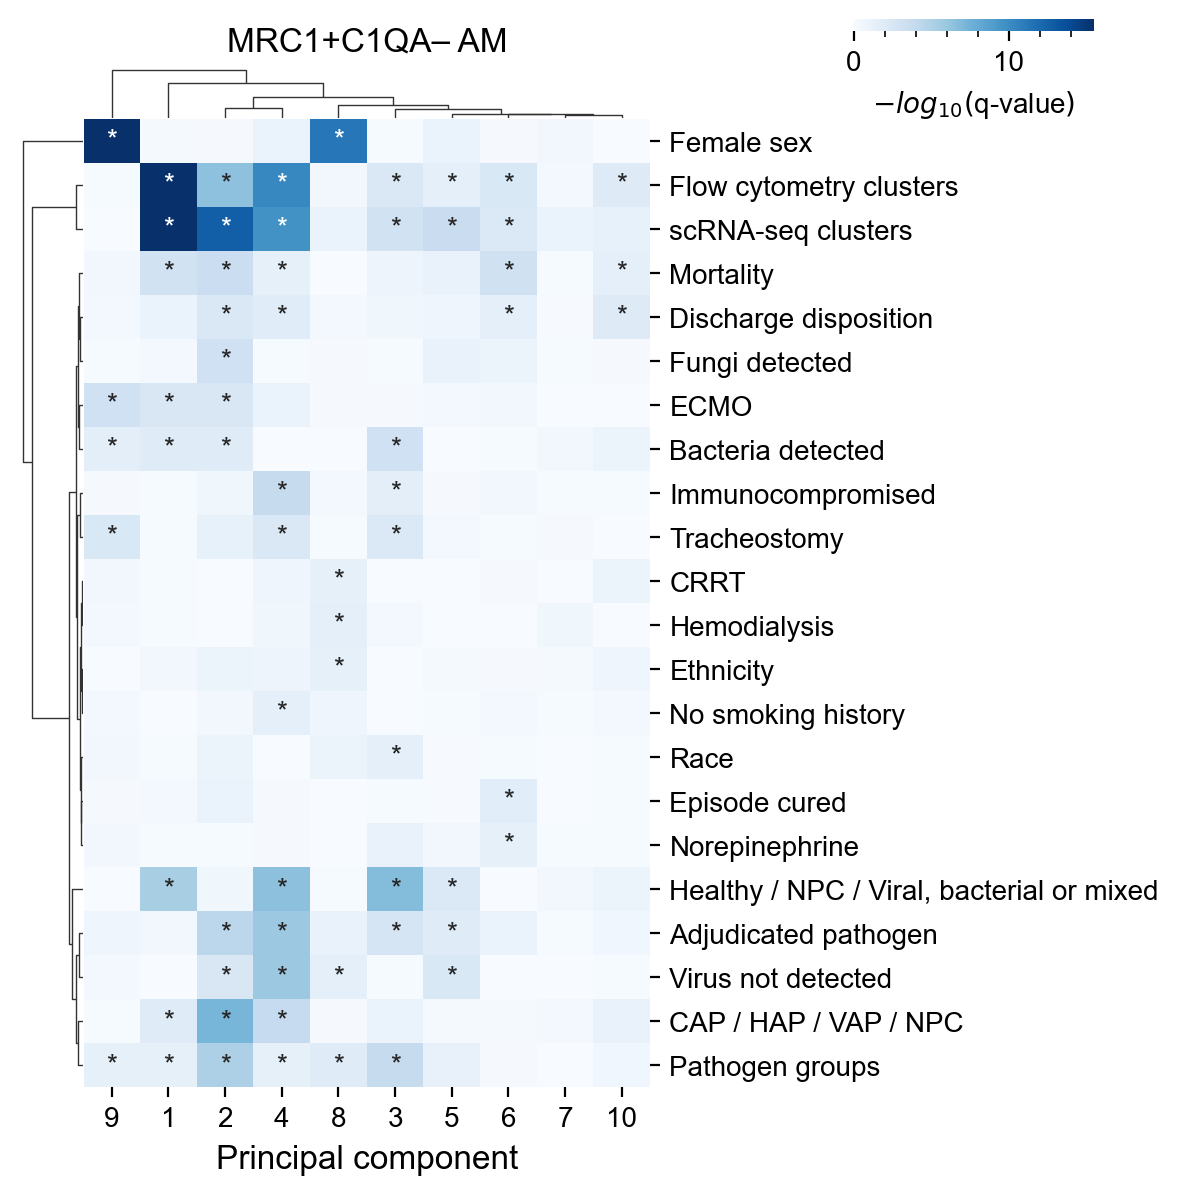

In [67]:
min_pval = pc_cat_assoc.to_numpy()[pc_cat_assoc != 0].min()
pc_cat_assoc[pc_cat_assoc == 0] = min_pval * 0.01
pc_annot = pd.DataFrame(index=pc_cat_assoc.index, columns=pc_cat_assoc.columns)
pc_annot[-np.log10(pc_cat_assoc) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    -np.log10(pc_cat_assoc).T,
    method='ward',
    cmap='Blues',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal'
    ),
    dendrogram_ratio=(0.1, 0.05),
    figsize=(6, 6),
    vmax=15.5,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=[PRETTY_CAT_NAMES.get(x, x.replace('_', ' ').replace('flag', '').strip()) for x in pc_cat_assoc.columns],
    xticklabels=pc_cat_assoc.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.figure.subplots_adjust(bottom=0.1, top=0.95)
cg.ax_cbar.set_position((0.72, 0.98, 0.2, 0.01))
cg.ax_cbar.set_xticks([2, 4, 6, 8, 12, 14], minor=True)
cg.ax_col_dendrogram.set_title(common_plots.CELL_TYPES_DISPLAY.get(cell_type.name, cell_type.name))
cg.figure.savefig(f'00_plots/17e_cat_heatmap_{cell_type.name}.pdf')

In [68]:
pc_corrs, pc_corr_pvals = fi.test_correlation(
    pc_df.loc[:, pc_names],
    numerical_covariates.loc[pc_df.index],
    na_values=dict(
        sequencing_depth=-1,
        sequencing_saturation=-1,
        frac_reads_in_cells=-1,
        viability=-1,
    )
)

In [69]:
to_keep = pc_corr_pvals.lt(0.05).sum().gt(0)
pc_corrs = pc_corrs.loc[:, to_keep].copy()
pc_corr_pvals = pc_corr_pvals.loc[:, to_keep].copy()

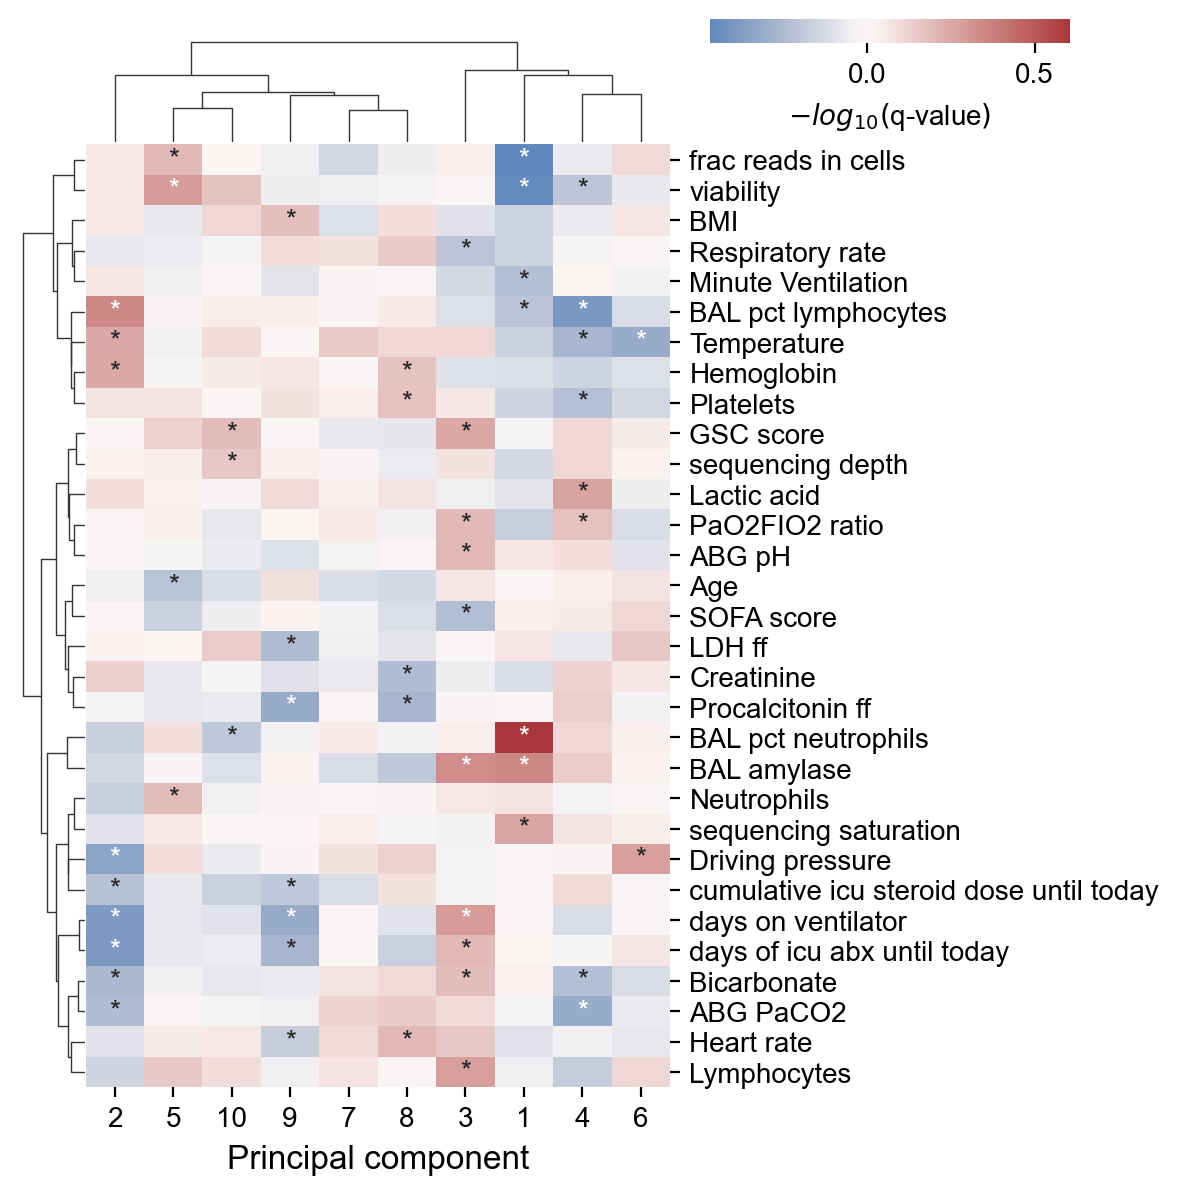

In [70]:
pc_annot = pd.DataFrame(index=pc_corr_pvals.index, columns=pc_corr_pvals.columns)
pc_annot[-np.log10(pc_corr_pvals) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    pc_corrs.T,
    method='ward',
    cmap='vlag',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal',
    ),
    dendrogram_ratio=0.1,
    figsize=(6, 6),
    center=0,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=pc_corrs.columns.str.replace('_', ' '),
    xticklabels=pc_corrs.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.fig.subplots_adjust(bottom=0.1)
cg.ax_cbar.set_position((0.6, 0.97, 0.3, 0.02))
# cg.fig.savefig(f'00_plots/16f_num_heatmap_{cell_type.name}.pdf')

In [71]:
cell_type = data[2]
print(cell_type.name)
pc_df = cell_type.get_pc_df(sample_meta)
pc_df.Pathogen_groups = pc_df.Pathogen_groups.cat.reorder_categories(
    common_plots.PATHOGEN_ORDER
)

CD8 T cells


Text(0.5, 1.0, 'CD8 T cells')

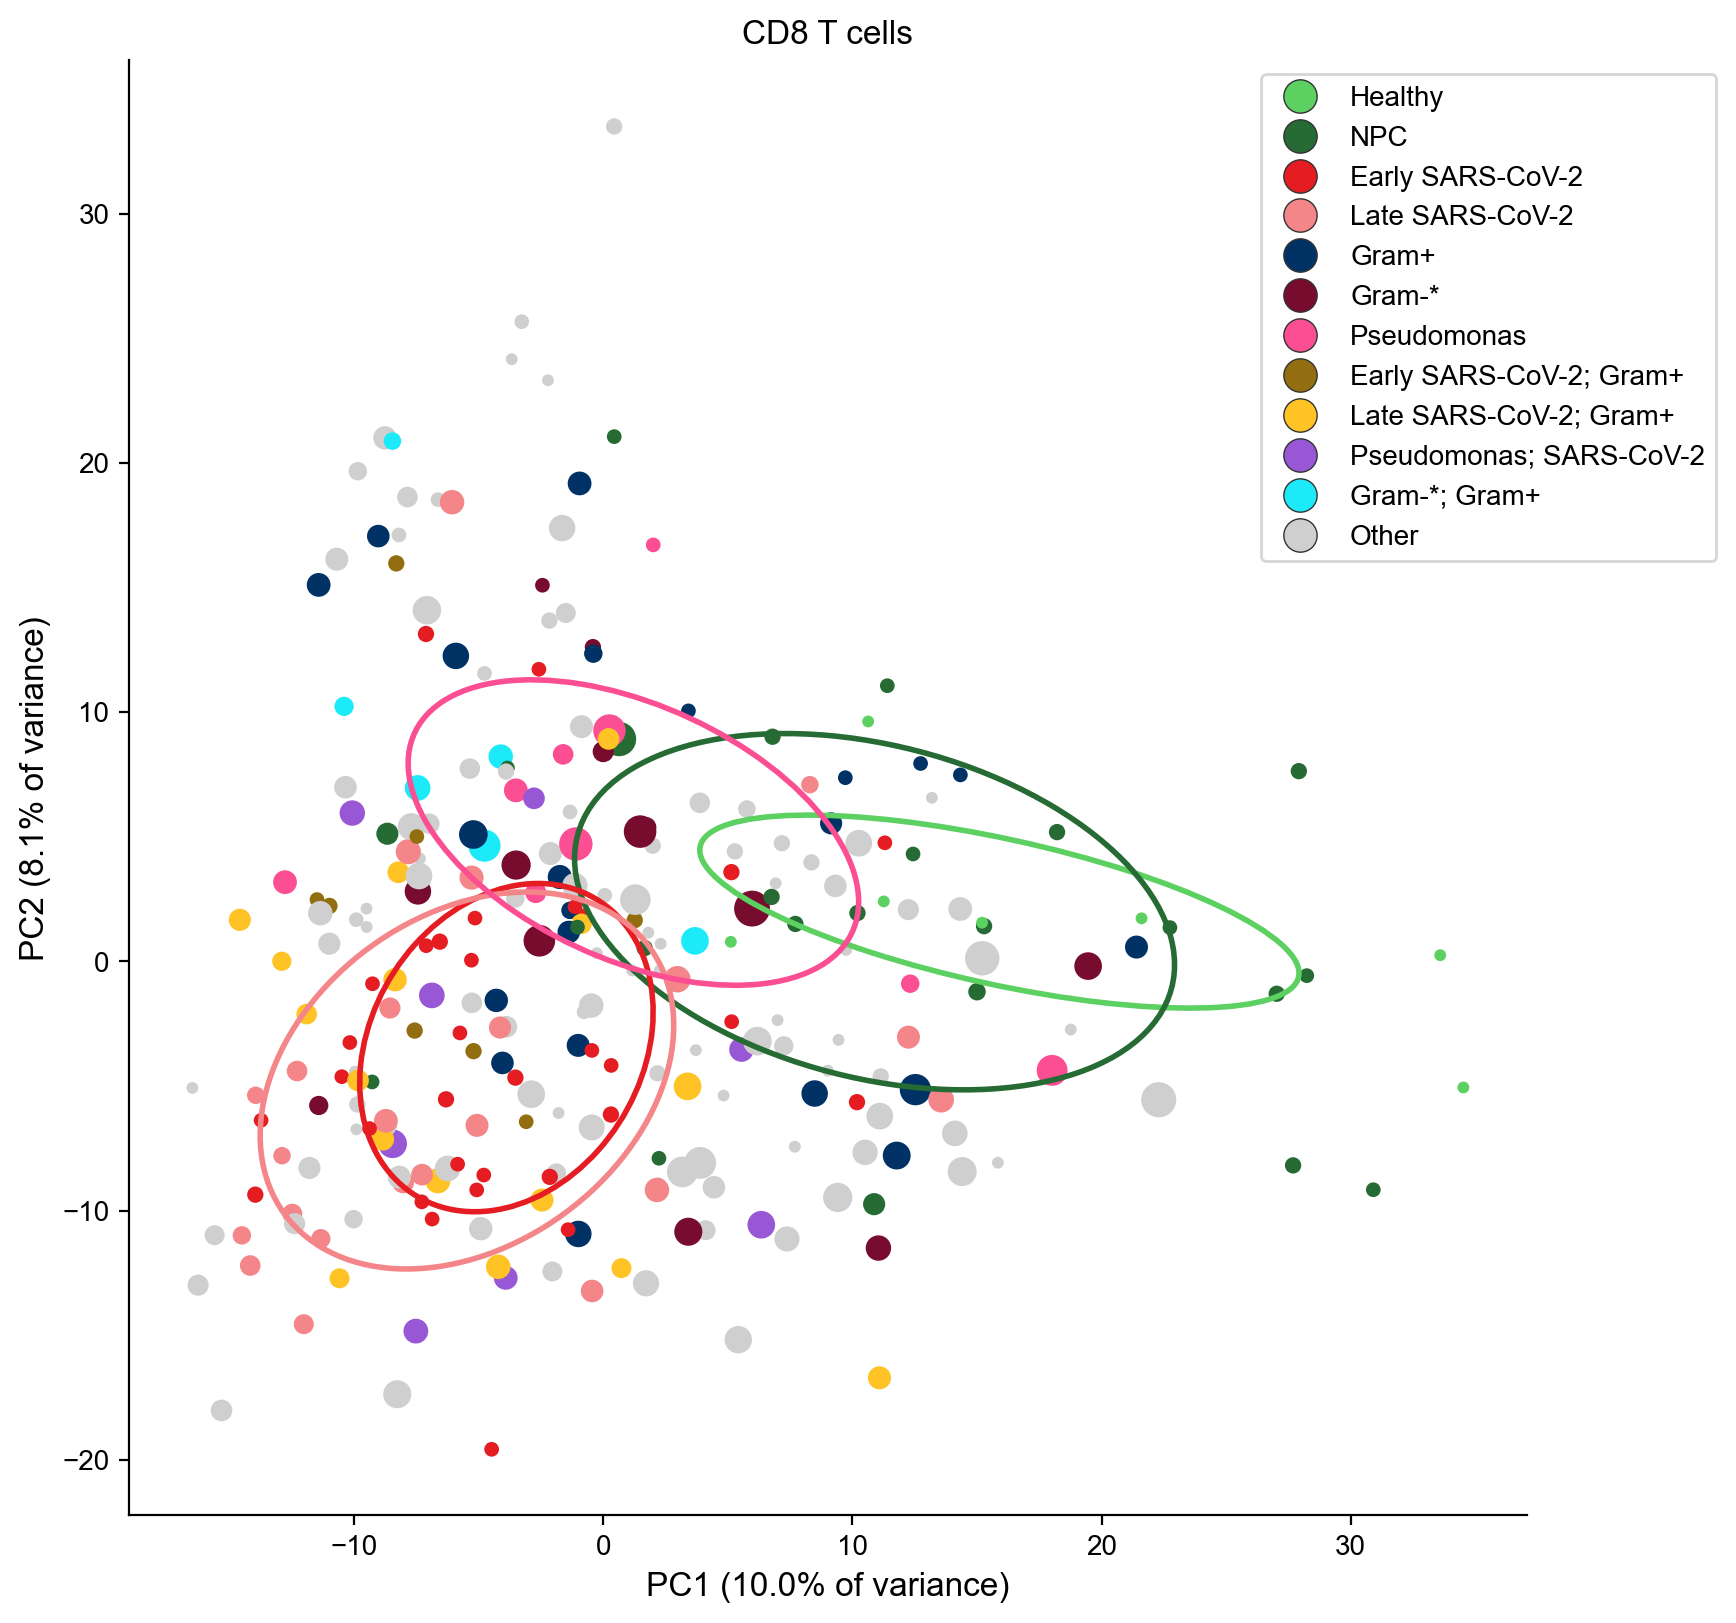

In [72]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.scatter(
    pc_df.PC1,
    pc_df.PC2,
    s=pc_df['size'] * 15,
    c=common_plots.get_color_annotations(pc_df, {
        'Pathogen_groups': [
            common_plots.PATHOGEN_PALETTE[cat]
            for cat
            in common_plots.PATHOGEN_ORDER
        ]
    }).Pathogen_groups
)
for cat in common_plots.PATHOGEN_ORDER:
    if cat not in ELLIPSES:
        continue
    idx = pc_df.Pathogen_groups.eq(cat)
    confidence_ellipse(
        pc_df.PC1[idx],
        pc_df.PC2[idx],
        ax,
        edgecolor=common_plots.PATHOGEN_PALETTE[cat],
        lw=2,
        n_std=1
    )
ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0], [0],
            ls='',
            marker='o',
            markerfacecolor=common_plots.PATHOGEN_PALETTE[cat],
            markeredgecolor='#333',
            markeredgewidth=0.5,
            markersize=12,
            label=cat if cat != 'discard' else 'Other'
        )
        for cat
        in common_plots.PATHOGEN_ORDER
    ],
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(0.8, 1),
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
pc1_label = f'PC1 ({cell_type.pca.explained_variance_ratio_[0] * 100:.1f}% of variance)'
pc2_label = f'PC2 ({cell_type.pca.explained_variance_ratio_[1] * 100:.1f}% of variance)'
ax.set_xlabel(pc1_label, size=12)
ax.set_ylabel(pc2_label, size=12)
ax.set_aspect('equal')
ax.set_title(cell_type.name)
# fig.savefig(f'00_plots/16f_pca_{cell_type.name}.pdf')

In [73]:
pc_names = pc_df.columns[pc_df.columns.str.startswith('PC')]
pc_df = pc_df.set_index('sample')

In [74]:
cat_covs = categorical_covariates.loc[pc_df.index].copy()
for col in cat_covs.columns:
    cat_covs[col] = cat_covs[col].cat.remove_unused_categories()

In [75]:
pc_cat_assoc = fi.test_association(
    pc_df.loc[:, pc_names],
    cat_covs,
    na_values,
    alternative_covariates=common_data.alternative_covariates
)
to_keep = pc_cat_assoc.lt(0.05).sum().gt(0)
pc_cat_assoc = pc_cat_assoc.loc[:, to_keep].copy()

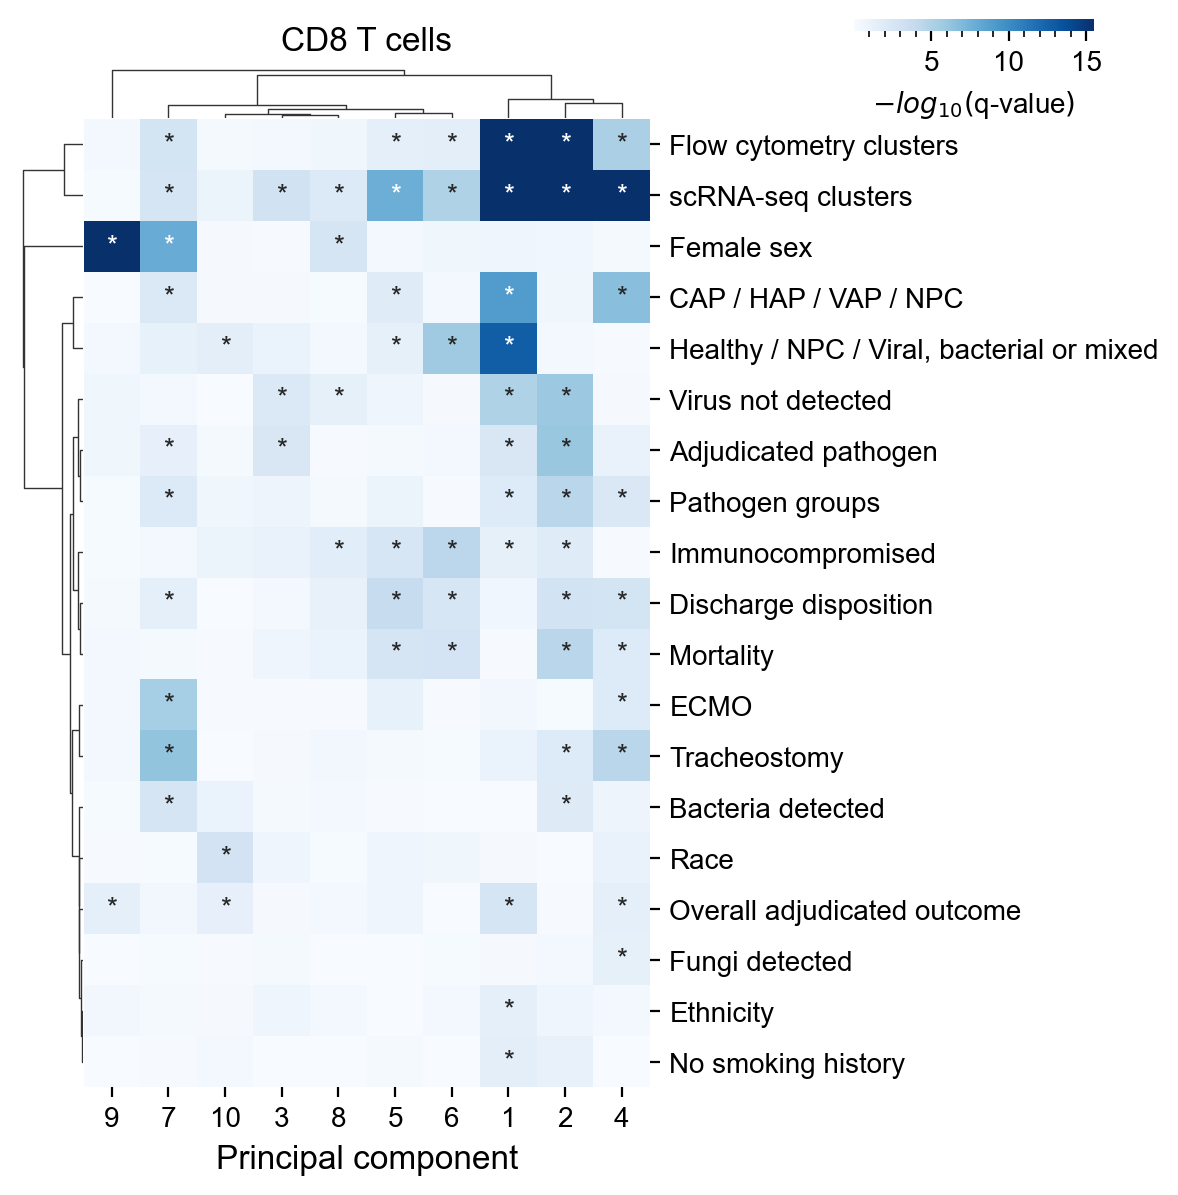

In [76]:
min_pval = pc_cat_assoc.to_numpy()[pc_cat_assoc != 0].min()
pc_cat_assoc[pc_cat_assoc == 0] = min_pval * 0.01
pc_annot = pd.DataFrame(index=pc_cat_assoc.index, columns=pc_cat_assoc.columns)
pc_annot[-np.log10(pc_cat_assoc) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    -np.log10(pc_cat_assoc).T,
    method='ward',
    cmap='Blues',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal'
    ),
    dendrogram_ratio=(0.1, 0.05),
    figsize=(6, 6),
    vmax=15.5,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=[PRETTY_CAT_NAMES.get(x, x.replace('_', ' ').replace('flag', '').strip()) for x in pc_cat_assoc.columns],
    xticklabels=pc_cat_assoc.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.figure.subplots_adjust(bottom=0.1, top=0.95)
cg.ax_cbar.set_position((0.72, 0.98, 0.2, 0.01))
cg.ax_cbar.set_xticks(range(1, 16), minor=True)
cg.ax_col_dendrogram.set_title(common_plots.CELL_TYPES_DISPLAY.get(cell_type.name, cell_type.name))
cg.figure.savefig(f'00_plots/17e_cat_heatmap_{cell_type.name}.pdf')

In [77]:
pc_corrs, pc_corr_pvals = fi.test_correlation(
    pc_df.loc[:, pc_names],
    numerical_covariates.loc[pc_df.index],
    na_values=dict(
        sequencing_depth=-1,
        sequencing_saturation=-1,
        frac_reads_in_cells=-1,
        viability=-1,
    )
)

In [78]:
to_keep = pc_corr_pvals.lt(0.05).sum().gt(0)
pc_corrs = pc_corrs.loc[:, to_keep].copy()
pc_corr_pvals = pc_corr_pvals.loc[:, to_keep].copy()

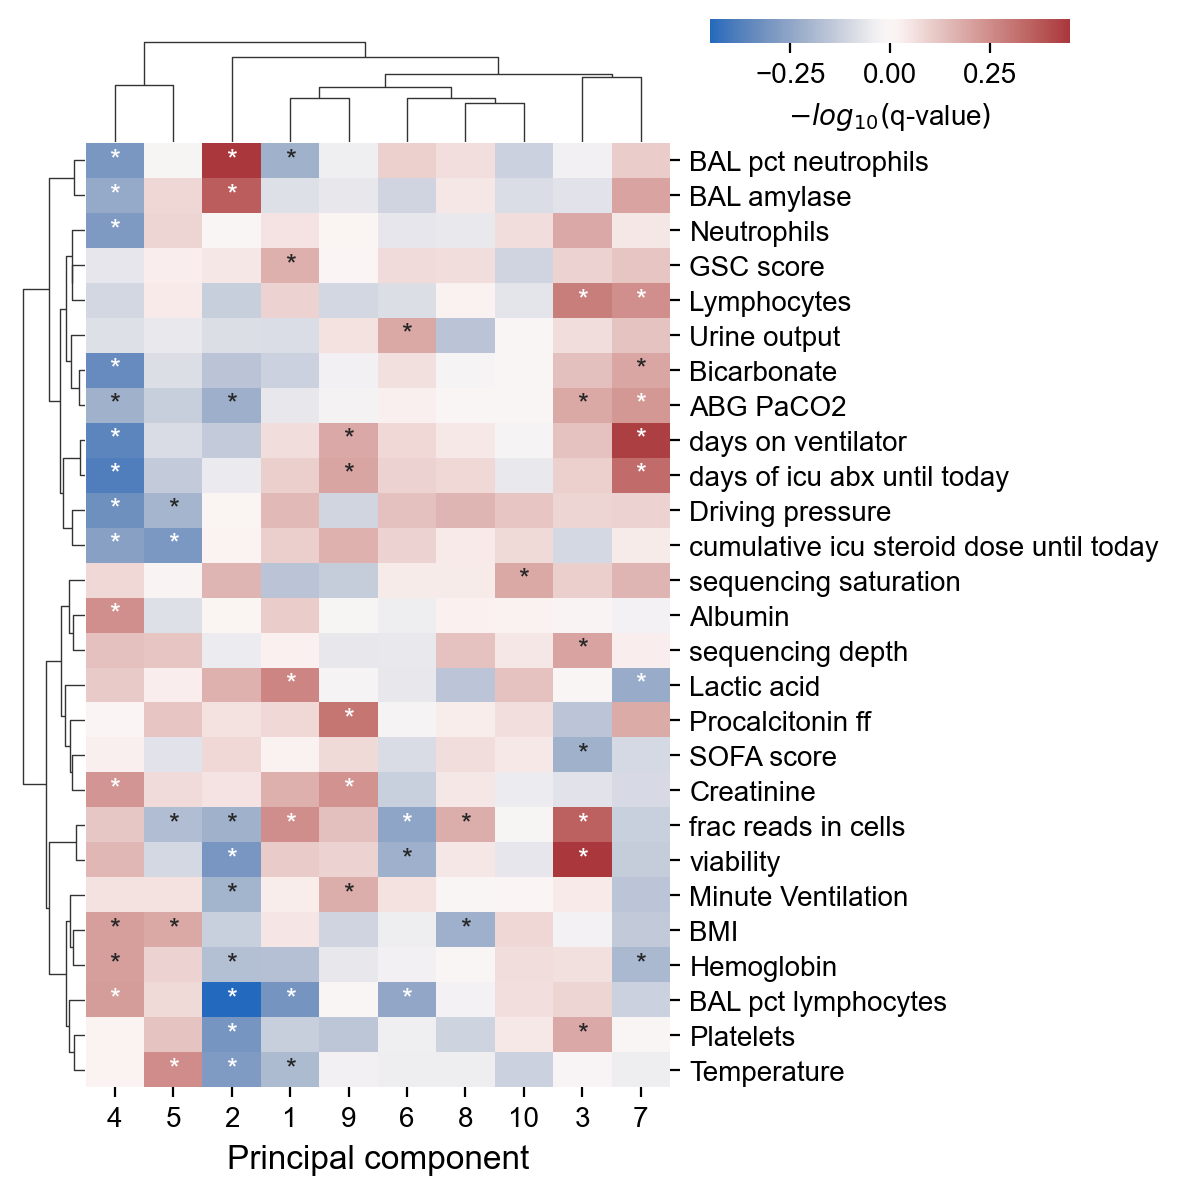

In [79]:
pc_annot = pd.DataFrame(index=pc_corr_pvals.index, columns=pc_corr_pvals.columns)
pc_annot[-np.log10(pc_corr_pvals) > -np.log10(0.05)] = '*'
pc_annot[pc_annot != '*'] = ''
cg = sns.clustermap(
    pc_corrs.T,
    method='ward',
    cmap='vlag',
    annot=pc_annot.T,
    fmt='s',
    cbar_kws=dict(
        label='$-log_{10}($q-value$)$',
        orientation='horizontal',
    ),
    dendrogram_ratio=0.1,
    figsize=(6, 6),
    center=0,
    cbar_pos=(0.75, 0.95, 0.2, 0.02),
    yticklabels=pc_corrs.columns.str.replace('_', ' '),
    xticklabels=pc_corrs.index.str.replace('PC', '')
)
cg.ax_heatmap.set_xlabel('Principal component', size=12)
cg.fig.subplots_adjust(bottom=0.1)
cg.ax_cbar.set_position((0.6, 0.97, 0.3, 0.02))
# cg.fig.savefig(f'00_plots/16f_num_heatmap_{cell_type.name}.pdf')